# Plot QC improvement with added FC

In [59]:
library(tidyverse)
library(ggplot2)

In [85]:
qc_asm_unphased <- read_tsv("../../assembly/qc/qc_flowcells_unphased.tsv", col_type = 'cdccc') 
head(qc_asm_unphased)

metric,value,haplotype,asm_method,asm_name,source
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Number of mapped sequences,19122,NA,unphased_verkko,TUE_02_01UL,stat
Number of primary alignments,45269,NA,unphased_verkko,TUE_02_01UL,stat
Number of secondary alignments,34659,NA,unphased_verkko,TUE_02_01UL,stat
Number of primary alignments with >65535 CIGAR operations,0,NA,unphased_verkko,TUE_02_01UL,stat
Number of bases in mapped sequences,6685275250,NA,unphased_verkko,TUE_02_01UL,stat
Number of mapped bases,6642871159,NA,unphased_verkko,TUE_02_01UL,stat


In [86]:
qc_asm <- read_tsv("../../assembly/qc/qc_flowcells.tsv", col_type = 'cdcccc') 
head(qc_asm)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Number of mapped sequences,539,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
Number of primary alignments,13130,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
Number of secondary alignments,4329,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
Number of primary alignments with >65535 CIGAR operations,0,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
Number of bases in mapped sequences,2907174214,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
Number of mapped bases,2877072421,haplotype1,phased_verkko,TUE_02_01UL,stat,NA


In [87]:
n_UL = c(1,2,3,4,5,6)
n_DX = c(0,1,2)
samples = c("TUE_02")

In [88]:
combinations <- as_tibble(expand.grid("n_UL" = n_UL, "n_DX" = as.factor(n_DX), "sample" = samples)) %>%
    mutate(asm_name = ifelse(n_DX == 0,
        paste0(sample,  "_", str_pad(n_UL, 2, pad = 0), "UL"),
        paste0(sample,  "_", str_pad(n_UL, 2, pad = 0), "UL", "_", str_pad(n_DX, 2, pad = "0"), "DX")))

In [90]:
dt <- inner_join(
  combinations,
  bind_rows(qc_asm, qc_asm_unphased),
  by = join_by("asm_name"),
)

head(dt)


n_UL,n_DX,sample,asm_name,metric,value,haplotype,asm_method,source,chromosome
<dbl>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,0,TUE_02,TUE_02_01UL,Number of mapped sequences,539,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of primary alignments,13130,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of secondary alignments,4329,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of primary alignments with >65535 CIGAR operations,0,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of bases in mapped sequences,2907174214,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of mapped bases,2877072421,haplotype1,phased_verkko,stat,NA


In [91]:
nrow(dt)
View(dt)

[1] 19728

n_UL,n_DX,sample,asm_name,metric,value,haplotype,asm_method,source,chromosome
<dbl>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,0,TUE_02,TUE_02_01UL,Number of mapped sequences,539,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of primary alignments,13130,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of secondary alignments,4329,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of primary alignments with >65535 CIGAR operations,0,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of bases in mapped sequences,2907174214,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of mapped bases,2877072421,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of substitutions,3921320,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,"Number of insertions in [0,50)",370666,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,"Number of insertions in [50,100)",3487,haplotype1,phased_verkko,stat,NA


In [109]:
source("../scripts/13_process_assembly_qc.R")

dt_processed <- process_qc_table(dt) %>% mutate(haplotype = ifelse(is.na(haplotype), "both", haplotype))

In [110]:
nrow(dt_processed)
View(dt_processed)

[1] 4050

n_UL,n_DX,sample,asm_name,metric,value,haplotype,asm_method,source,chromosome
<dbl>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,0,TUE_02,TUE_02_01UL,Assembly Length,2.907174e+09,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,% of Ref covered by Assembly,8.873000e-01,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,% of Ref duplicated in Assembly,1.360000e-02,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,% of Assembly covered by Ref,9.651000e-01,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,NG75,5.833740e+07,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,NG50,1.352128e+08,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,NGA50,3.011018e+06,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,Average Ungapped Alignment length,4.012744e+06,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,Number of Breaks in Assembly,1.176100e+04,haplotype1,phased_verkko,asmstat,NA


In [111]:
metrics <- dt_processed %>% select('metric') %>% unique() %>% pull()
for (i in 1:length(metrics))
{
    print(paste("Plotting", metrics[i]))
    p <- ggplot(dt_processed %>% filter(metric == metrics[i]), aes(x = n_UL, y = value, col = n_DX)) +
        #geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        geom_line(aes(linetype = haplotype)) +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c( "#E69F00", "#56B4E9", "#009E73","#999999", "#F0E442")) +
        facet_wrap(~asm_method) +
        theme_classic() +
        labs(
            x = "n UL Flowcells",
            y = metrics[i],
            fill = "n DX Flowcells"
         )
    ggsave(paste0("../../doc/img/flowcells/", metrics[i], ".png"), p)
}

[1] "Plotting Assembly Length"


Saving 7 x 7 in image


[1] "Plotting % of Ref covered by Assembly"


Saving 7 x 7 in image


[1] "Plotting % of Ref duplicated in Assembly"


...

Saving 7 x 7 in image


[1] "Plotting Genome Completeness"


Saving 7 x 7 in image


[1] "Plotting Missing Multi-Copy Genes (%)"


Saving 7 x 7 in image


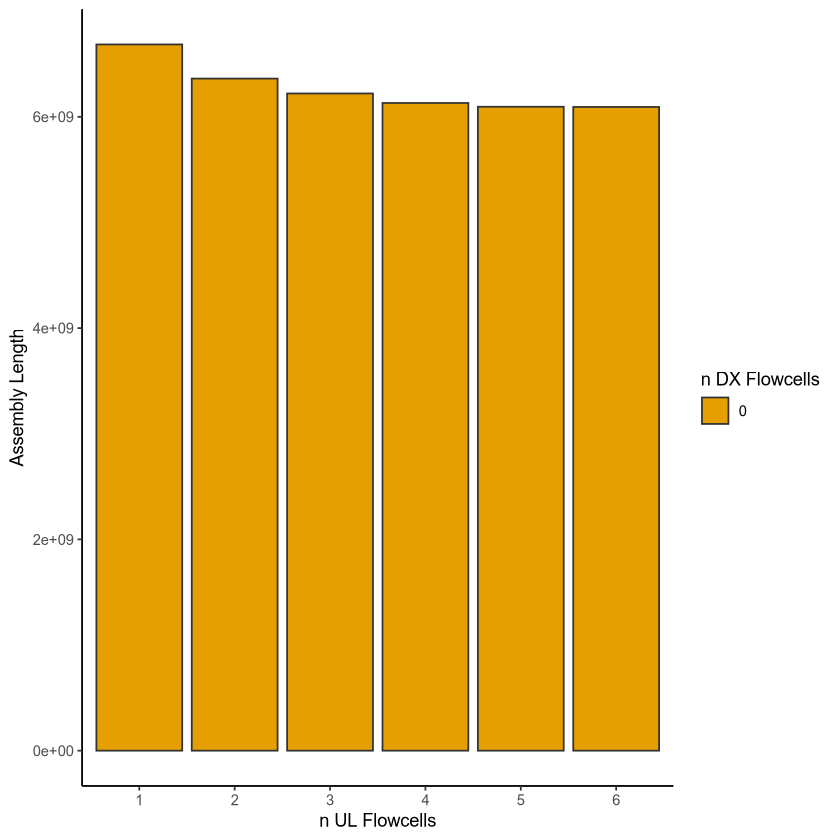

In [68]:
m <- "Assembly Length"

